<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [12]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [13]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [14]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


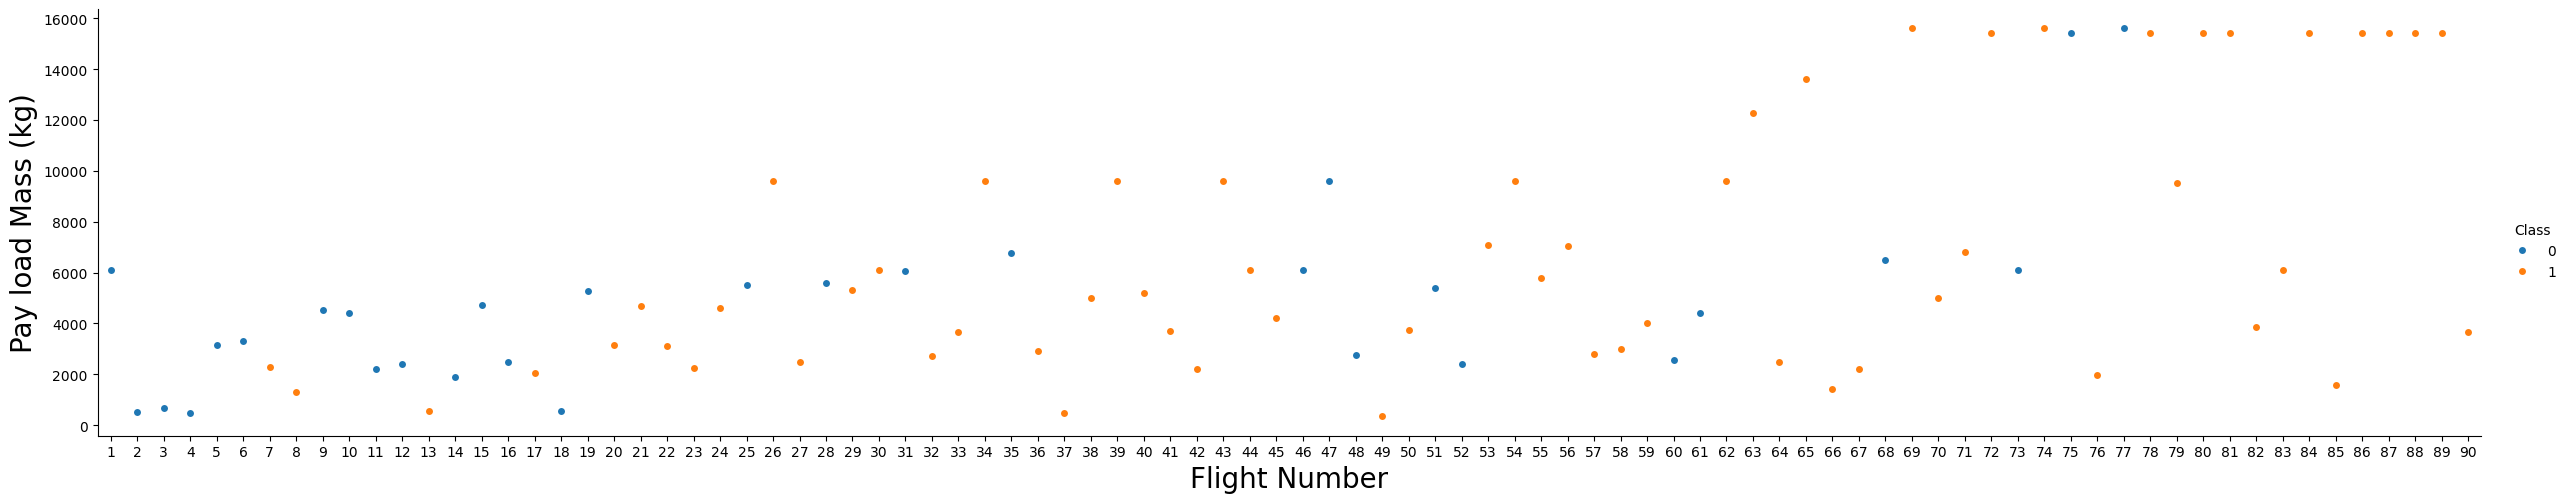

In [15]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

In [10]:
%pip install seaborn

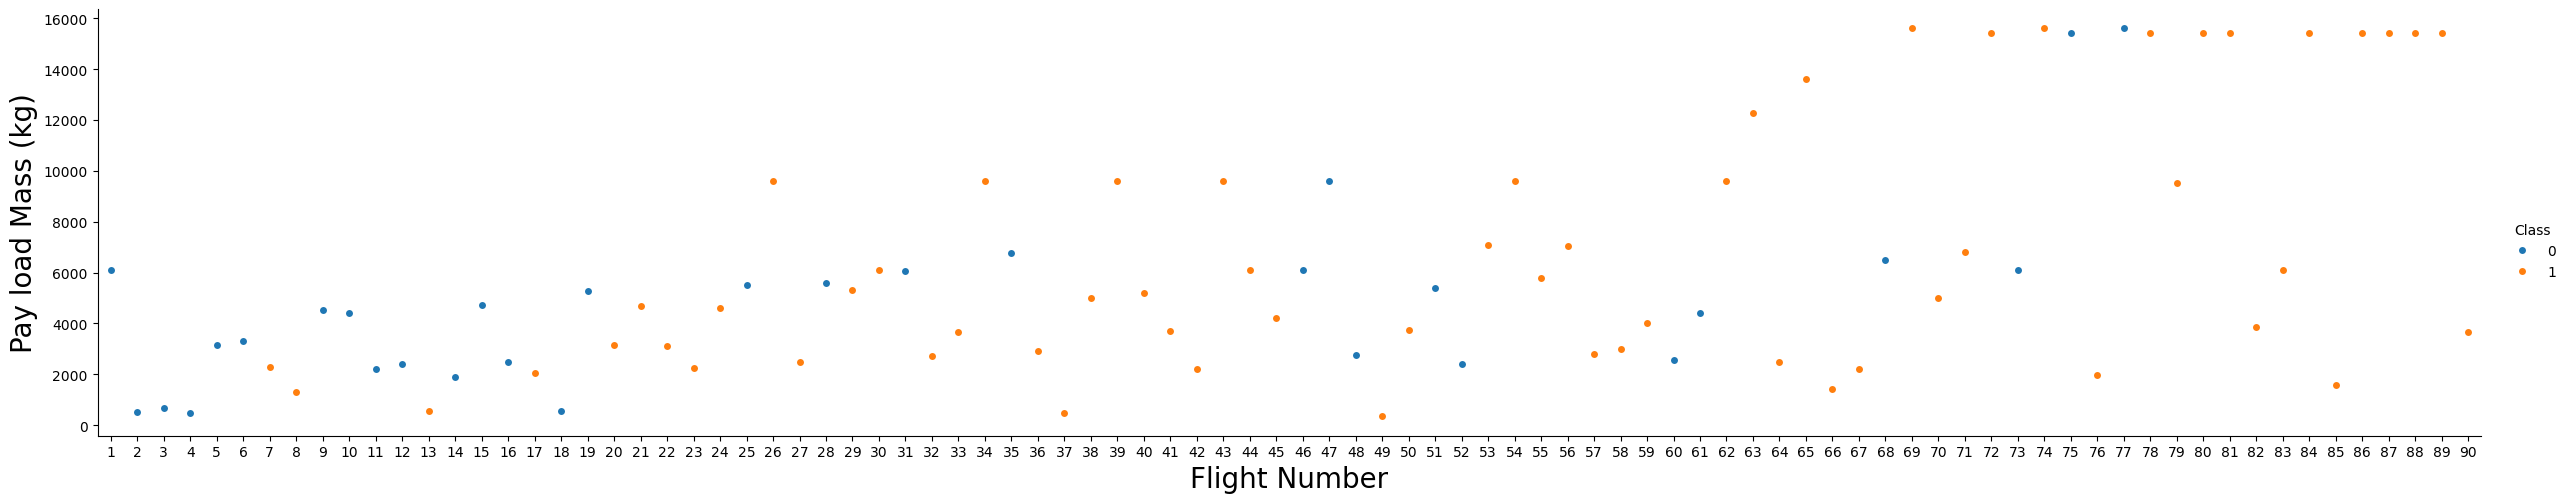

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create and capture the categorical plot
g = sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)

# 2. Apply the axis labels
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay load Mass (kg)", fontsize=20)

# 3. Save the figure FIRST ( dpi=300 makes it look crisp in PPT )
g.savefig('my_scatterplot.png', dpi=300, bbox_inches='tight')

# 4. Display the plot
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


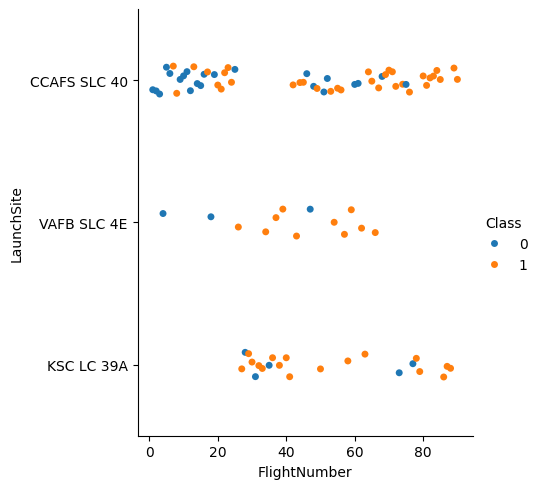

In [9]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
sns.catplot(x='FlightNumber', y='LaunchSite', hue='Class', data=df, kind='strip')  # or kind='point', 'swarm', etc.
plt.show()

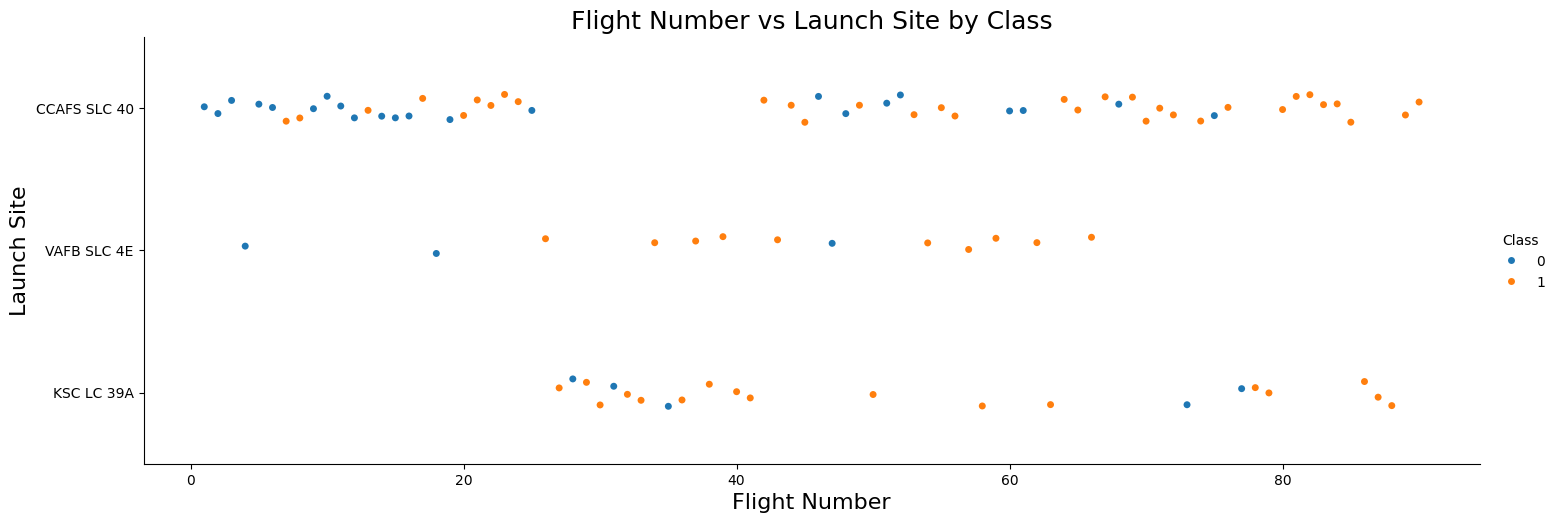

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create and capture the categorical plot for Launch Sites
g = sns.catplot(x='FlightNumber', y='LaunchSite', hue='Class', data=df, aspect=3)

# 2. Add clear titles and labels so it looks great in your slides
plt.xlabel("Flight Number", fontsize=16)
plt.ylabel("Launch Site", fontsize=16)
plt.title("Flight Number vs Launch Site by Class", fontsize=18)

# 3. Save the figure with a new name (dpi=300 keeps it high-res)
g.savefig('launch_site_scatterplot.png', dpi=300, bbox_inches='tight')

# 4. Display the plot
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


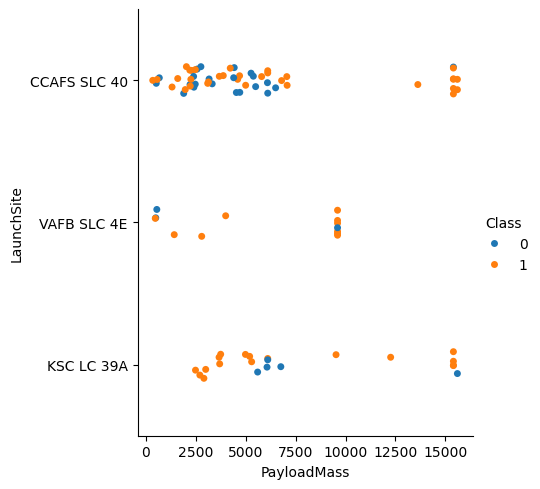

In [14]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
sns.catplot(x='PayloadMass', y='LaunchSite', hue='Class', data=df, kind='strip')
plt.show()

Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


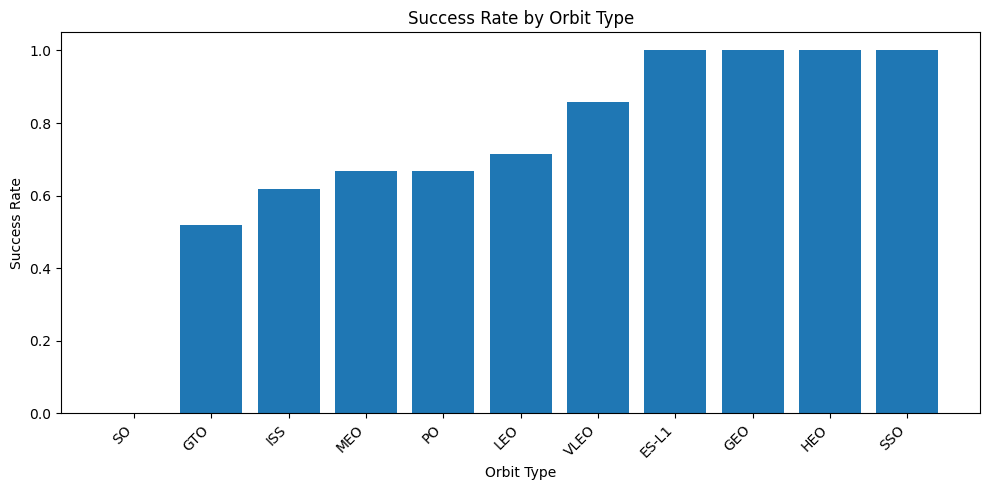

In [19]:
# HINT use groupby method on Orbit column and get the mean of Class column
import pandas as pd
import matplotlib.pyplot as plt

# success rate for each orbit type
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
orbit_success = orbit_success.sort_values('Class')

# plot
plt.figure(figsize=(10,5))
plt.bar(orbit_success['Orbit'], orbit_success['Class'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Success Rate')
plt.xlabel('Orbit Type')
plt.title('Success Rate by Orbit Type')
plt.tight_layout()
plt.show()

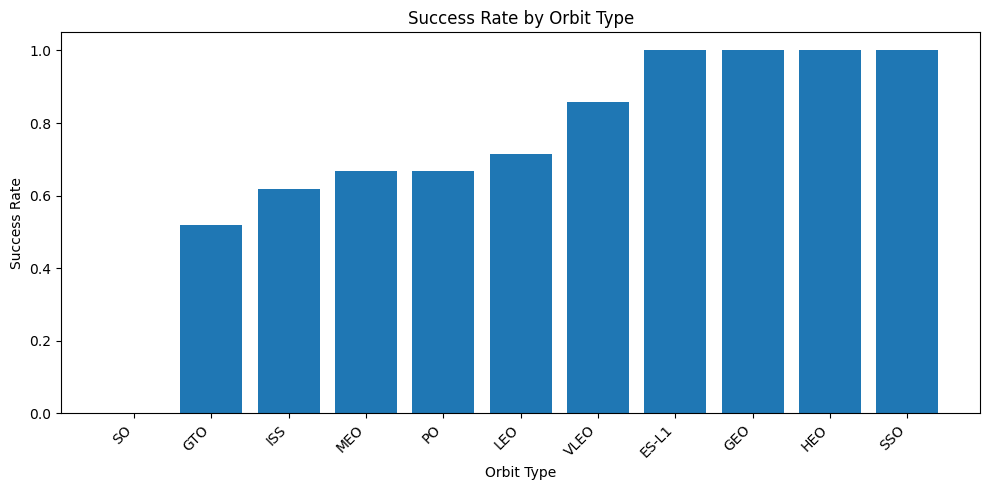

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate success rate for each orbit type
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
orbit_success = orbit_success.sort_values('Class')

# 2. Setup the plot figure size
plt.figure(figsize=(10, 5))

# 3. Build the bar chart
plt.bar(orbit_success['Orbit'], orbit_success['Class'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Success Rate')
plt.xlabel('Orbit Type')
plt.title('Success Rate by Orbit Type')

# 4. Save the figure FIRST (dpi=300 keeps it crystal clear for PPT)
plt.savefig('orbit_success_rate.png', dpi=300, bbox_inches='tight')

# 5. Display the plot
plt.tight_layout()
plt.show()

Analyze the plotted bar chart to identify which orbits have the highest success rates.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


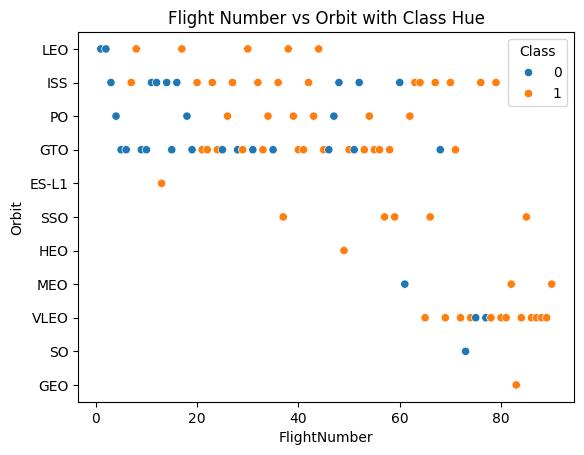

In [19]:
sns.scatterplot(x='FlightNumber', y='Orbit', hue='Class', data=df)
plt.title('Flight Number vs Orbit with Class Hue')
plt.show()

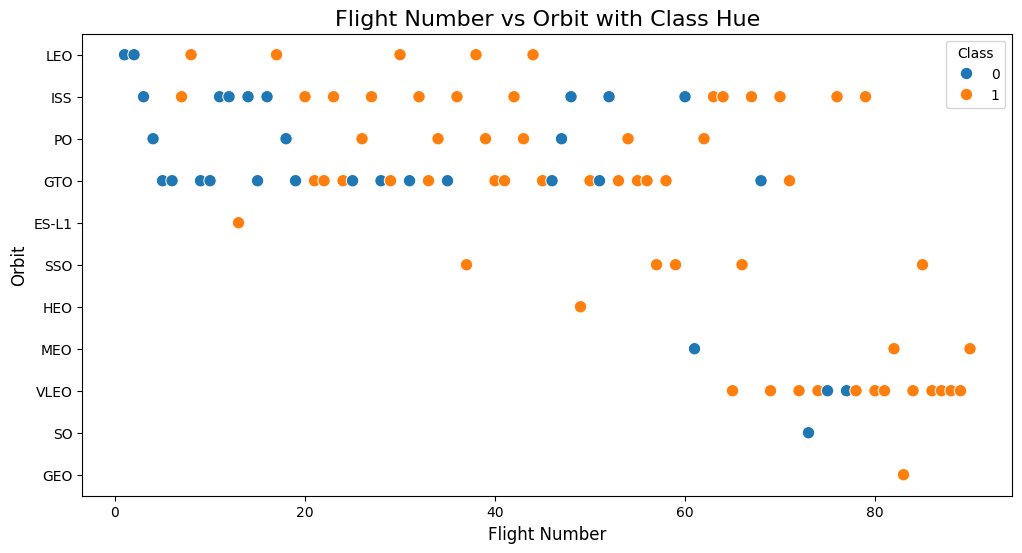

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the figure size so the orbit names have room to breathe
plt.figure(figsize=(12, 6))

# 2. Generate the scatterplot
sns.scatterplot(x='FlightNumber', y='Orbit', hue='Class', data=df, s=80)

# 3. Add titles and adjust layout
plt.title('Flight Number vs Orbit with Class Hue', fontsize=16)
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Orbit', fontsize=12)

# 4. Save the figure FIRST (giving it a unique name)
plt.savefig('flight_vs_orbit_scatter.png', dpi=300, bbox_inches='tight')

# 5. Display the plot
plt.show()

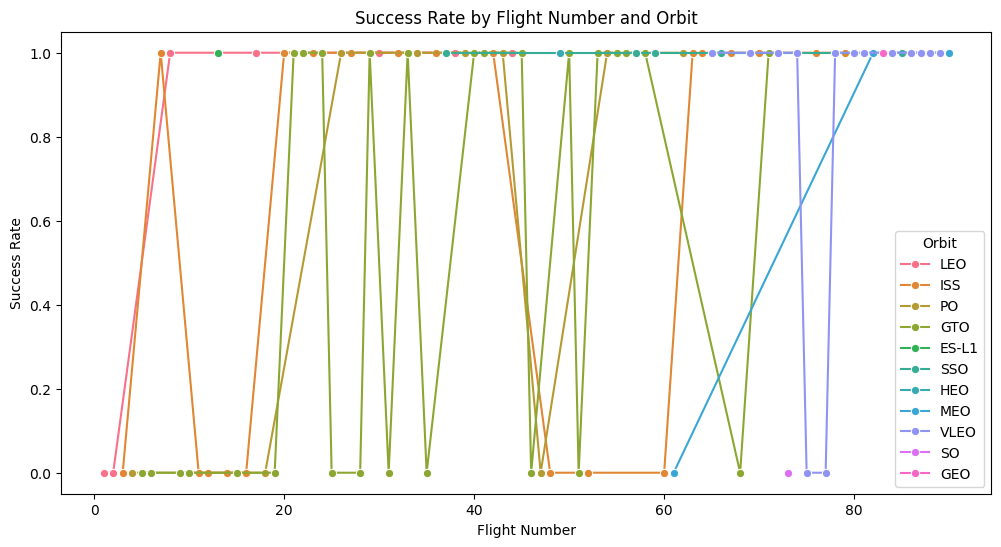

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df and has columns 'FlightNumber', 'Orbit', and 'class'

# Calculate success rate grouped by FlightNumber and Orbit
success_rate = df.groupby(['FlightNumber', 'Orbit'])['Class'].mean().reset_index()

# Plotting success rate with FlightNumber on x-axis, Orbit as hue
plt.figure(figsize=(12,6))
sns.lineplot(data=success_rate, x='FlightNumber', y='Class', hue='Orbit', marker='o')
plt.title('Success Rate by Flight Number and Orbit')
plt.ylabel('Success Rate')
plt.xlabel('Flight Number')
plt.legend(title='Orbit')
plt.show()

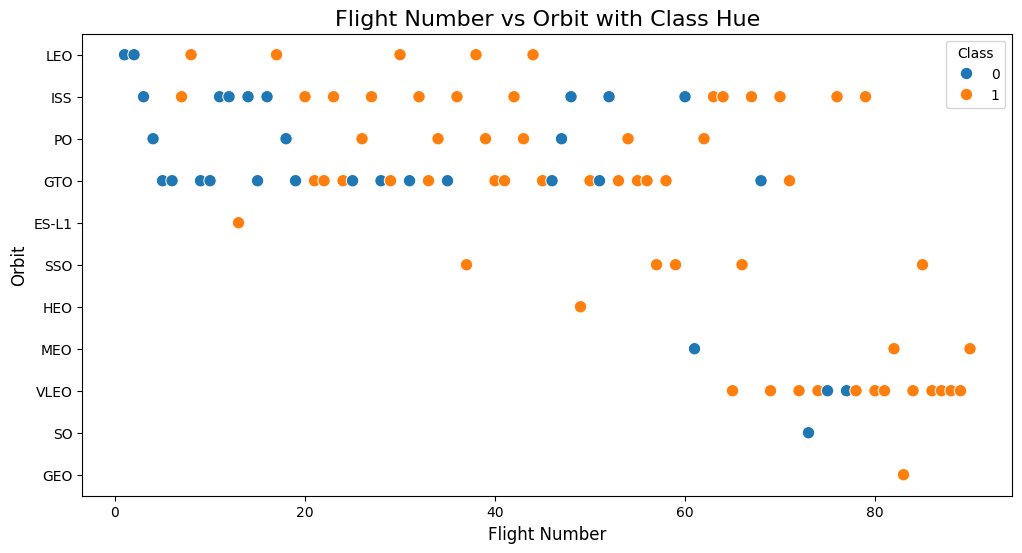

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the figure size so the orbit names have room to breathe
plt.figure(figsize=(12, 6))

# 2. Generate the scatterplot
sns.scatterplot(x='FlightNumber', y='Orbit', hue='Class', data=df, s=80)

# 3. Add titles and adjust layout
plt.title('Flight Number vs Orbit with Class Hue', fontsize=16)
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Orbit', fontsize=12)

# 4. Save the figure FIRST (giving it a unique name)
plt.savefig('flight_vs_orbit_scatter.png', dpi=300, bbox_inches='tight')

# 5. Display the plot
plt.show()

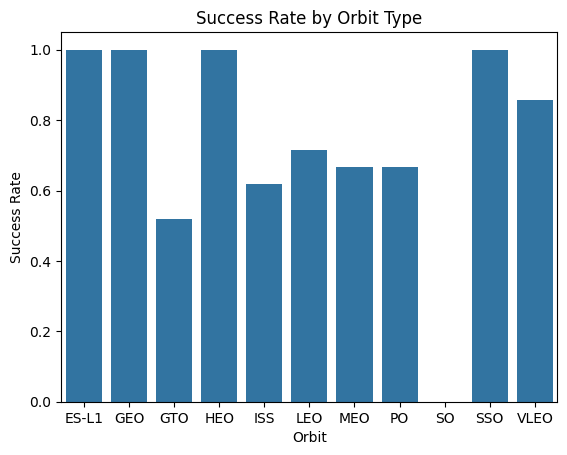

In [16]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df and has columns 'Orbit' and 'class'
success_rate = df.groupby('Orbit')['Class'].mean().reset_index()

# Plotting the bar chart
sns.barplot(x='Orbit', y='Class', data=success_rate)
plt.ylabel('Success Rate')
plt.title('Success Rate by Orbit Type')
plt.show()

You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.


### TASK  5: Visualize the relationship between Payload Mass and Orbit type


Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


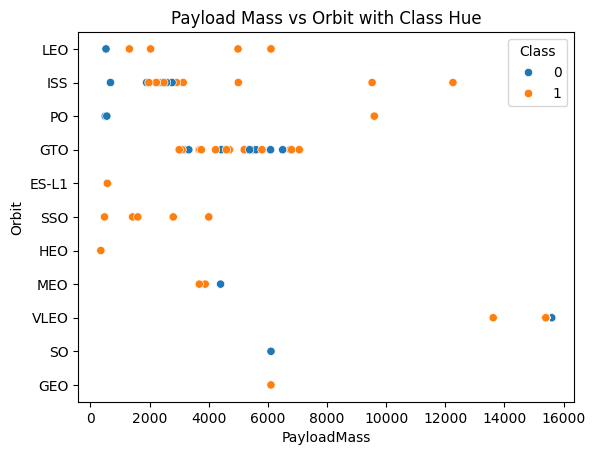

In [20]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df and column is 'Payload Mass' (check exact column name)
sns.scatterplot(x='PayloadMass', y='Orbit', hue='Class', data=df)
plt.title('Payload Mass vs Orbit with Class Hue')
plt.show()

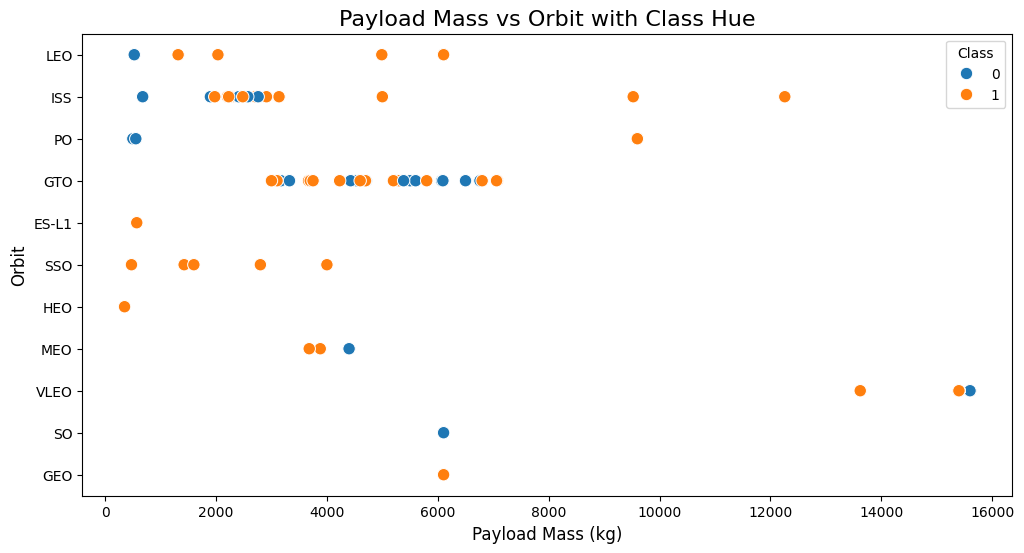

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set a wider figure size so the orbit distributions look clear
plt.figure(figsize=(12, 6))

# 2. Generate the scatterplot (s=80 makes the dots slightly larger and easier to see)
sns.scatterplot(x='PayloadMass', y='Orbit', hue='Class', data=df, s=80)

# 3. Add clear titles and axis labels
plt.title('Payload Mass vs Orbit with Class Hue', fontsize=16)
plt.xlabel('Payload Mass (kg)', fontsize=12)
plt.ylabel('Orbit', fontsize=12)

# 4. Save the figure for your PowerPoint (dpi=300 ensures high resolution)
plt.savefig('payload_vs_orbit_scatter.png', dpi=300, bbox_inches='tight')

# 5. Display the plot
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [21]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


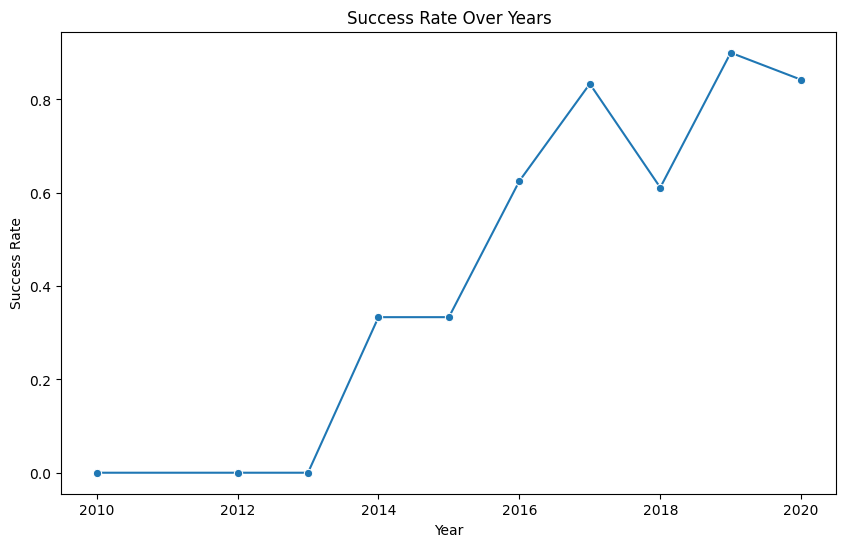

In [22]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'Date' column to datetime if not already
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Calculate success rate per year
success_rate_year = df.groupby('Year')['Class'].mean().reset_index()

# Plot line chart
plt.figure(figsize=(10,6))
sns.lineplot(data=success_rate_year, x='Year', y='Class', marker='o')
plt.title('Success Rate Over Years')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.show()

you can observe that the sucess rate since 2013 kept increasing till 2020


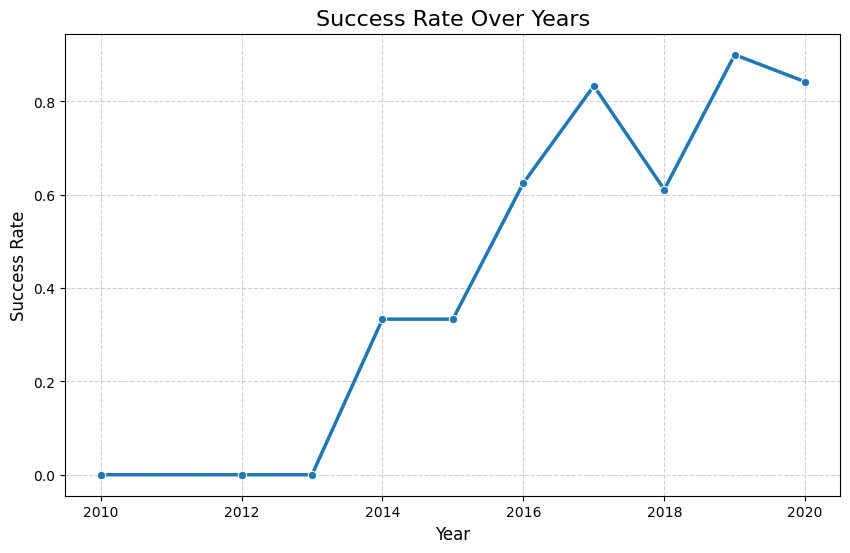

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the year from the Date column
df['Year'] = pd.to_datetime(df['Date']).dt.year

# 2. Calculate the average success rate per year
success_rate_year = df.groupby('Year')['Class'].mean().reset_index()

# 3. Setup the figure size
plt.figure(figsize=(10, 6))

# 4. Plot the line chart (marker='o' adds clean dots to each year's data point)
sns.lineplot(data=success_rate_year, x='Year', y='Class', marker='o', linewidth=2.5)

# 5. Add clear titles and labels
plt.title('Success Rate Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Adds a clean grid background for easier reading

# 6. Save the figure FIRST (giving it a unique name)
plt.savefig('success_rate_over_years.png', dpi=300, bbox_inches='tight')

# 7. Display the plot
plt.show()

## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [23]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [24]:
# HINT: Use get_dummies() function on the categorical columns
import pandas as pd

# DataFrame is named features
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# Display the first few rows
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>


In [25]:
# HINT: use astype function
features_one_hot = features_one_hot.astype('float64')

# Verify the data types
features_one_hot.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


In [25]:
df.columns

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'Class', 'Year'],
      dtype='object')

In [26]:
unique_launch_sites = sorted(df['LaunchSite'].dropna().unique())
unique_launch_sites

['CCAFS SLC 40', 'KSC LC 39A', 'VAFB SLC 4E']

In [27]:
cca_launch = df[df['LaunchSite'].str.startswith('CCA')].head(5)
cca_launch

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,2010
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,2012
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,2013
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,2013
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857,0,2014


In [29]:
df['LaunchSite'].dropna().unique()[:20]

array(['CCAFS SLC 40', 'VAFB SLC 4E', 'KSC LC 39A'], dtype=object)

In [30]:
nasa_launch_sites = ['CCAFS SLC 40', 'VAFB SLC 4E', 'KSC LC 39A']

total_payload_nasa = df[df['LaunchSite'].isin(nasa_launch_sites)]['PayloadMass'].sum()
total_payload_nasa

549446.3470588236

In [35]:
avg_payload_f9_v11 = df.loc[df['Block'] == 2, 'PayloadMass'].mean()
avg_payload_f9_v11

3848.1666666666665

In [37]:
df[['Date','Outcome','LandingPad','Class']].head()


,Date,Outcome,LandingPad,Class
0,2010-06-04,None None,NaN,0
1,2012-05-22,None None,NaN,0
2,2013-03-01,None None,NaN,0
3,2013-09-29,False Ocean,NaN,0
4,2013-12-03,None None,NaN,0


In [39]:
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])

mask = (df['Class'] == 1) & (df['LandingPad'].notna()) & (~df['Outcome'].astype(str).str.contains('Ocean', na=False))

first_success_ground_date = df.loc[mask].sort_values('Date')['Date'].head(1)
first_success_ground_date

16   2015-12-22
Name: Date, dtype: datetime64[ns]

In [40]:
df['LandingPad'].dropna().unique()

array(['5e9e3032383ecb761634e7cb', '5e9e3032383ecb6bb234e7ca',
       '5e9e3032383ecb267a34e7c7', '5e9e3033383ecbb9e534e7cc',
       '5e9e3032383ecb554034e7c9'], dtype=object)

In [41]:
df[['Outcome','LandingPad']].dropna().head(10)
df['Outcome'].dropna().unique()[:20]

array(['None None', 'False Ocean', 'True Ocean', 'False ASDS',
       'None ASDS', 'True RTLS', 'True ASDS', 'False RTLS'], dtype=object)

In [42]:
mask = (
    df['Outcome'].astype(str).str.contains('ASDS', na=False) &
    df['Outcome'].astype(str).str.startswith('True') &
    (df['PayloadMass'] > 4000) &
    (df['PayloadMass'] < 6000)
)

boosters = df.loc[mask, 'BoosterVersion'].dropna().unique()
boosters

array(['Falcon 9'], dtype=object)

In [43]:
success_count = (df['Class'] == 1).sum()
failure_count = (df['Class'] == 0).sum()

success_count, failure_count

(60, 30)

In [44]:
max_payload = df['PayloadMass'].max()

boosters_max_payload = (
    df.loc[df['PayloadMass'] == max_payload, 'BoosterVersion']
      .dropna()
      .unique()
)

boosters_max_payload

array(['Falcon 9'], dtype=object)

In [45]:
# filter: 2015 + drone ship (ASDS) + failure
mask = (
    (df['Year'] == 2015) &
    (df['Outcome'].astype(str).str.contains('ASDS', na=False)) &
    (df['Class'] == 0)
)

cols = ['Outcome', 'BoosterVersion', 'LaunchSite']
failed_drone_ship_2015 = df.loc[mask, cols]

failed_drone_ship_2015

,Outcome,BoosterVersion,LaunchSite
11,False ASDS,Falcon 9,CCAFS SLC 40
13,False ASDS,Falcon 9,CCAFS SLC 40
15,None ASDS,Falcon 9,CCAFS SLC 40


In [46]:
import pandas as pd

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter date range (inclusive)
start_date = pd.to_datetime('2010-06-04')
end_date = pd.to_datetime('2017-03-20')

df_range = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# Build a label like: "Success (ground pad)" or "Failure (drone ship)"
# In your dataset, "ASDS" indicates drone ship, and "RTLS" / ground-pad type generally means not ASDS.
is_drone_ship = df_range['Outcome'].astype(str).str.contains('ASDS', na=False)

df_range['LandingType'] = pd.Series(
    ['drone ship' if x else 'ground pad' for x in is_drone_ship],
    index=df_range.index
)

df_range['MissionResult'] = df_range['Class'].apply(lambda v: 'Success' if v == 1 else 'Failure')

df_range['OutcomeLabel'] = df_range['MissionResult'] + ' (' + df_range['LandingType'] + ')'

# Rank by counts (descending)
ranked_counts = (
    df_range['OutcomeLabel']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'LandingOutcome', 'OutcomeLabel': 'Count'})
)

ranked_counts

,Count,count
0,Failure (ground pad),11
1,Success (ground pad),6
2,Failure (drone ship),6
3,Success (drone ship),5


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
